In [1]:
# setup
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
batch1 = pickle.load(open(r'../data/batch1.pkl', 'rb'))

#remove batteries that do not reach 80% capacity
del batch1['b1c8']
del batch1['b1c10']
del batch1['b1c12']
del batch1['b1c13']
del batch1['b1c22']

In [3]:
numBat1 = len(batch1.keys())
numBat1

41

In [4]:
batch2 = pickle.load(open(r'../Data/batch2.pkl','rb'))

In [5]:
# There are four cells from batch1 that carried into batch2, we'll remove the data from batch2
# and put it with the correct cell from batch1
batch2_keys = ['b2c7', 'b2c8', 'b2c9', 'b2c15', 'b2c16']
batch1_keys = ['b1c0', 'b1c1', 'b1c2', 'b1c3', 'b1c4']
add_len = [662, 981, 1060, 208, 482];

In [6]:
for i, bk in enumerate(batch1_keys):
    batch1[bk]['cycle_life'] = batch1[bk]['cycle_life'] + add_len[i]
    for j in batch1[bk]['summary'].keys():
        if j == 'cycle':
            batch1[bk]['summary'][j] = np.hstack((batch1[bk]['summary'][j], batch2[batch2_keys[i]]['summary'][j] + len(batch1[bk]['summary'][j])))
        else:
            batch1[bk]['summary'][j] = np.hstack((batch1[bk]['summary'][j], batch2[batch2_keys[i]]['summary'][j]))
    last_cycle = len(batch1[bk]['cycles'].keys())
    for j, jk in enumerate(batch2[batch2_keys[i]]['cycles'].keys()):
        batch1[bk]['cycles'][str(last_cycle + j)] = batch2[batch2_keys[i]]['cycles'][jk]

In [7]:
del batch2['b2c7']
del batch2['b2c8']
del batch2['b2c9']
del batch2['b2c15']
del batch2['b2c16']

In [8]:
numBat2 = len(batch2.keys())
numBat2

43

In [9]:
batch3 = pickle.load(open(r'../data/batch3.pkl','rb'))
# remove noisy channels from batch3
del batch3['b3c37']
del batch3['b3c2']
del batch3['b3c23']
del batch3['b3c32']
del batch3['b3c42']
del batch3['b3c43']

In [10]:
numBat3 = len(batch3.keys())
numBat3

40

In [11]:
numBat = numBat1 + numBat2 + numBat3
numBat

124

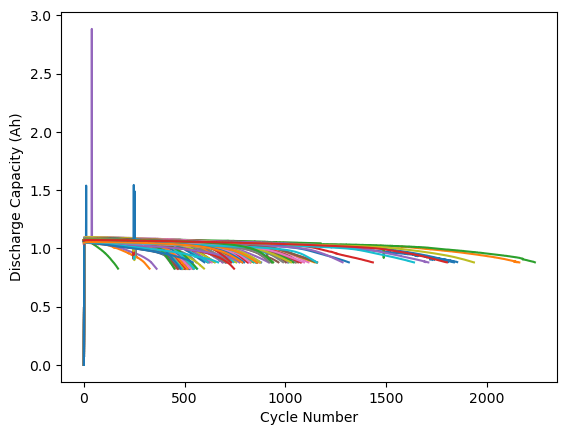

In [12]:
bat_dict = {**batch1, **batch2, **batch3}
for i in bat_dict.keys():
    plt.plot(bat_dict[i]['summary']['cycle'], bat_dict[i]['summary']['QD'])
    plt.xlabel('Cycle Number')
    plt.ylabel('Discharge Capacity (Ah)')

In [17]:
batch4 = pickle.load(open(r'../data/batch4.pkl', 'rb'))


In [19]:
# remove channel 7 to stay consistent with authors
batDict = {**batch1, **batch2, **batch3, **batch4}

In [20]:
# print cell descriptor keys
cell = batDict['b1c0']
print(cell.keys())

dict_keys(['cycle_life', 'charge_policy', 'summary', 'cycles'])


In [23]:
# print cell summary keys and shape
print(cell['summary'].keys())
print({k: v.shape for k, v in cell['summary'].items()})

# print cell summary keys and shape
print(cell['charge_policy'])

dict_keys(['IR', 'QC', 'QD', 'Tavg', 'Tmin', 'Tmax', 'chargetime', 'cycle'])
{'IR': (1851,), 'QC': (1851,), 'QD': (1851,), 'Tavg': (1851,), 'Tmin': (1851,), 'Tmax': (1851,), 'chargetime': (1851,), 'cycle': (1851,)}
3.6C(80%)-3.6C


In [24]:
# print cell cycles keys and shape
cycle = cell['cycles']['0']
print(cycle.keys())
print({k: v.shape for k, v in cycle.items()})

dict_keys(['I', 'Qc', 'Qd', 'Qdlin', 'T', 'Tdlin', 'V', 'dQdV', 't'])
{'I': (2,), 'Qc': (2,), 'Qd': (2,), 'Qdlin': (2,), 'T': (2,), 'Tdlin': (2,), 'V': (2,), 'dQdV': (2,), 't': (2,)}


In [21]:
print(f"Total:   {len(batDict)} cells")

Total:   169 cells


In [22]:
with open('../data/batDict.pkl', 'wb') as f:
    pickle.dump(batDict, f)